In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MU = 40.0 # nonlinearity factor
#T_FINAL = 24.0 (No need for this anymore, t_final is defined later)
X0 = 1.0 # initial position x(0)
V0 = 0.0 # initial velocity x'(0)

PERIOD_MARGIN = 1.15
ROUGH_PERIOD_FACTOR = 1.614
N_PERIODS_SETTLE = 4

N_WINDOWS_TARGET = 10 # initial equidistribution target: actual count may grow via MAX_WINDOW_WIDTH splitting
LAYERS = (1, 32, 32, 32, 32, 1)
N_COLLOCATION_PER_WINDOW = 2000
COLLOCATION_SCALE_CAP = 3.0
ADAM_EPOCHS = 3000
ADAM_LR = 1e-3
GRAD_CLIP_NORM = 10.0
LBFGS_MAX_ITER = 2000
PRINT_EVERY = 500

# Adaptive collocation resampling
RESAMPLE_EVERY = 500
RESAMPLE_CANDIDATE_MULT = 5
RESAMPLE_UNIFORM_FLOOR = 0.2

# Non-uniform window placement
COARSE_N_POINTS = 4000
MIN_WINDOW_WIDTH = 0.15
MAX_WINDOW_WIDTH = 3.0
MONITOR_VELOCITY_WEIGHT = 0.4
MONITOR_ACCEL_WEIGHT = 0.6

# Convergence retry
LOSS_CONVERGENCE_THRESHOLD = 1e-4
MAX_RETRIES_PER_WINDOW = 2

Using device: cuda


In [2]:
# Finds period of van der pol using reference solution to define T_FINAL
def van_der_pol_rhs(t, y, mu=MU):
    x, v = y
    return [v, mu * (1 - x ** 2) * v - x]

def estimate_vdp_period(mu, x0=X0, v0=V0, rough_factor=ROUGH_PERIOD_FACTOR, n_settle=N_PERIODS_SETTLE):
    rough_T = rough_factor * mu
    t_span = n_settle * max(rough_T, 5.0)
    def event_peak(t, y):
        return y[1]
    event_peak.direction = -1

    sol = solve_ivp(
        lambda t, y: van_der_pol_rhs(t, y, mu=mu),
        [0.0, t_span], [x0, v0],
        events=event_peak, rtol=1e-10, atol=1e-12, max_step=0.05,
    )
    peak_times = sol.t_events[0]
    if len(peak_times) < 3:
        print(f"[period detection] not enough peaks found, falling back to rough estimate {rough_T:.3f}")
        return rough_T
    period = peak_times[-1] - peak_times[-2]
    return period

vdp_period = estimate_vdp_period(MU)
T_FINAL = float(PERIOD_MARGIN * vdp_period)
print(f"Detected VdP period at mu={MU}: {vdp_period:.4f}  ->  T_FINAL = {T_FINAL:.4f}")

Detected VdP period at mu=40.0: 66.5014  ->  T_FINAL = 76.4766


In [3]:
class BasePINN(nn.Module):
    # Shared architecture skeleton: encode_input() + trunk_forward()

    def __init__(self):
        super().__init__()

    def encode_input(self, t):
        raise NotImplementedError

    def trunk_forward(self, encoded):
        raise NotImplementedError

    def forward(self, t):
        return self.trunk_forward(self.encode_input(t))

    @staticmethod
    def init_linear(linear):
        nn.init.xavier_normal_(linear.weight)
        nn.init.zeros_(linear.bias)

In [4]:
class VanillaPINN(BasePINN):
    # Standard PINN architecture
    def __init__(self, t_start, window_size, layers=LAYERS):
        super().__init__()
        self.t_start = t_start
        self.window_size = window_size
        self.trunk = nn.ModuleList()
        for i in range(len(layers) - 1):
            linear = nn.Linear(layers[i], layers[i + 1])
            self.init_linear(linear)
            self.trunk.append(linear)
        self.activation = torch.tanh

    def encode_input(self, t):
        tau = t - self.t_start
        return (2.0 * tau / self.window_size) - 1.0

    def trunk_forward(self, encoded):
        out = encoded
        for layer in self.trunk[:-1]:
            out = self.activation(layer(out))
        return self.trunk[-1](out)

In [5]:
class WindowPINN(nn.Module):
    """
    Time-marching wrapper, wraps base architecture (VanillaPINN) and enforces this window's initial condition exactly:
    x(t) = x0_local + v0_local * tau + tau^2 * base_model(t)
    """
    def __init__(self, base_model, t_start, window_size, x0_local, v0_local):
        super().__init__()
        self.base_model = base_model
        self.t_start = t_start
        self.window_size = window_size
        self.x0_local = x0_local
        self.v0_local = v0_local

    def forward(self, t):
        tau = t - self.t_start
        n_raw = self.base_model(t)
        return self.x0_local + self.v0_local * tau + (tau ** 2) * n_raw

In [6]:
def physics_residual(model, t, mu=MU):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True, retain_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True, retain_graph=True)[0]
    return x_tt - mu * (1.0 - x ** 2) * x_t + x

def compute_loss(model, t_f):
    # only the physics residual; IC is hard-enforced, no loss_ic term
    f_pred = physics_residual(model, t_f)
    return torch.mean(f_pred ** 2)

def sample_collocation_points(t_start, t_end, n):
    t_f = np.random.uniform(low=t_start, high=t_end, size=(n, 1))
    t_f = torch.tensor(t_f, dtype=torch.get_default_dtype(), device=device)
    t_f.requires_grad_(True)
    return t_f

def evaluate_state(model, t_value):
    # (x, x') of a trained window model at a single time becomes the hard IC handed to the next window
    t_tensor = torch.tensor([[t_value]], dtype=torch.get_default_dtype(), device=device, requires_grad=True)
    x = model(t_tensor)
    x_t = torch.autograd.grad(x, t_tensor, grad_outputs=torch.ones_like(x))[0]
    return x.item(), x_t.item()

In [7]:
def adaptive_collocation_points(model, t_start, t_end, n_points, n_candidates_mult=RESAMPLE_CANDIDATE_MULT, uniform_floor=RESAMPLE_UNIFORM_FLOOR):
    # Draw a large uniform candidate pool, score each candidate by the current model's physics-residual magnitude, then keep points preferentially where the residual is large
    n_candidates = max(n_points * n_candidates_mult, n_points)
    t_candidates_np = np.random.uniform(t_start, t_end, size=(n_candidates, 1))
    t_candidates = torch.tensor(t_candidates_np, dtype=torch.get_default_dtype(), device=device)
    t_candidates.requires_grad_(True)
    residual = physics_residual(model, t_candidates)
    scores = (residual.detach() ** 2).cpu().numpy().flatten()
    scores += 1e-12
    probs = scores / scores.sum()
    n_weighted = int(round(n_points * (1.0 - uniform_floor)))
    n_uniform = n_points - n_weighted
    weighted_idx = np.random.choice(n_candidates, size=n_weighted, replace=False, p=probs)
    t_weighted_np = t_candidates_np[weighted_idx]
    t_uniform_np = np.random.uniform(t_start, t_end, size=(n_uniform, 1))
    t_new_np = np.vstack([t_weighted_np, t_uniform_np])
    t_new = torch.tensor(t_new_np, dtype=torch.get_default_dtype(), device=device)
    t_new.requires_grad_(True)
    return t_new

def compute_nonuniform_window_edges(n_windows, t_final=T_FINAL, mu=MU, x0=X0, v0=V0, coarse_n_points=COARSE_N_POINTS, min_width=MIN_WINDOW_WIDTH, max_width=MAX_WINDOW_WIDTH):
    t_coarse = np.linspace(0.0, t_final, coarse_n_points)
    sol = solve_ivp(lambda t, y: van_der_pol_rhs(t, y, mu=mu), [0.0, t_final], [x0, v0], t_eval=t_coarse, method="RK45", rtol=1e-9, atol=1e-9)
    x_c, v_c = sol.y[0], sol.y[1]
    accel = mu * (1 - x_c ** 2) * v_c - x_c
    vel_norm = np.abs(v_c) / (np.abs(v_c).max() + 1e-12)
    acc_norm = np.abs(accel) / (np.abs(accel).max() + 1e-12)
    monitor = MONITOR_VELOCITY_WEIGHT * vel_norm + MONITOR_ACCEL_WEIGHT * acc_norm
    cumulative = np.concatenate([[0.0], np.cumsum(0.5 * (monitor[1:] + monitor[:-1]) * np.diff(t_coarse))])
    total_measure = cumulative[-1]
    targets = np.linspace(0.0, total_measure, n_windows + 1)
    edges = np.interp(targets, cumulative, t_coarse)
    edges[0], edges[-1] = 0.0, t_final
    for i in range(1, len(edges) - 1):
        if edges[i] - edges[i - 1] < min_width:
            edges[i] = edges[i - 1] + min_width
    edges = np.clip(edges, 0.0, t_final)
    edges[-1] = t_final
    for i in range(len(edges) - 2, 0, -1):
        if edges[i + 1] - edges[i] < min_width:
            edges[i] = edges[i + 1] - min_width
    edges = np.clip(edges, 0.0, t_final)
    edges[0], edges[-1] = 0.0, t_final
    edges = np.unique(edges)
    new_edges = [edges[0]]
    for i in range(len(edges) - 1):
        a, b = edges[i], edges[i + 1]
        width = b - a
        n_sub = max(int(np.ceil(width / max_width)), 1)
        sub_edges = np.linspace(a, b, n_sub + 1)[1:]
        new_edges.extend(sub_edges.tolist())
    edges = np.unique(np.array(new_edges))
    return edges, t_coarse, monitor

In [8]:
def run_adam_phase(model, t_start, t_end, n_points, adam_epochs, window_idx, tag="Adam"):
    t_f = sample_collocation_points(t_start, t_end, n_points)
    history = []
    optimizer = torch.optim.Adam(model.parameters(), lr=ADAM_LR)
    for epoch in range(adam_epochs):
        if epoch > 0 and epoch % RESAMPLE_EVERY == 0:
            t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
        optimizer.zero_grad()
        loss = compute_loss(model, t_f)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        history.append(loss.item())
        if epoch % PRINT_EVERY == 0:
            print(f"[window {window_idx}] [{tag}]  epoch {epoch:5d} | loss {loss.item():.3e}")
    return history, t_f

def run_lbfgs_phase(model, t_f, max_iter, window_idx, tag="L-BFGS"):
    history = []
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=max_iter, tolerance_grad=1e-9, tolerance_change=1e-12, history_size=50, line_search_fn="strong_wolfe")
    counter = {"n": 0}
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = compute_loss(model, t_f)
        loss.backward()
        history.append(loss.item())
        counter["n"] += 1
        if counter["n"] % PRINT_EVERY == 0:
            print(f"[window {window_idx}] [{tag}] iter {counter['n']:5d} | loss {loss.item():.3e}")
        return loss
    optimizer_lbfgs.step(closure)
    return history

In [9]:
def train_window(model, t_start, t_end, n_points, adam_epochs, window_idx=0):
    history, t_f = run_adam_phase(model, t_start, t_end, n_points, adam_epochs, window_idx, tag="Adam")
    t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
    history += run_lbfgs_phase(model, t_f, LBFGS_MAX_ITER, window_idx, tag="L-BFGS")

    # convergence check + automatic retries with fresh adaptive resampling
    retries = 0
    while history[-1] > LOSS_CONVERGENCE_THRESHOLD and retries < MAX_RETRIES_PER_WINDOW:
        retries += 1
        print(f"[window {window_idx}] loss {history[-1]:.3e} > {LOSS_CONVERGENCE_THRESHOLD:.1e} threshold "
              f"-> retry {retries}/{MAX_RETRIES_PER_WINDOW}")
        t_f = adaptive_collocation_points(model, t_start, t_end, n_points)
        history += run_lbfgs_phase(model, t_f, LBFGS_MAX_ITER, window_idx, tag=f"L-BFGS-retry{retries}")

    return history

In [10]:
window_edges, coarse_t, coarse_monitor = compute_nonuniform_window_edges(N_WINDOWS_TARGET)
window_widths = np.diff(window_edges)
n_windows_actual = len(window_widths)
mean_width = window_widths.mean()
print(f"Non-uniform window edges (t): {np.round(window_edges, 3)}")
print(f"Window widths: {np.round(window_widths, 3)}")
print(f"Actual window count after MAX_WIDTH splitting: {n_windows_actual} (target was {N_WINDOWS_TARGET})")

start_time = time.time()

models = []
full_history = []
x0_cur, v0_cur = X0, V0
prev_base_state = None
for w in range(n_windows_actual):
    t_start = float(window_edges[w])
    t_end = float(window_edges[w + 1])
    width = t_end - t_start
    # scale collocation points and Adam epochs by window width relative to the mean
    width_ratio = width / mean_width
    n_points_w = int(round(N_COLLOCATION_PER_WINDOW * np.clip(width_ratio, 1.0, COLLOCATION_SCALE_CAP)))
    adam_epochs_w = int(round(ADAM_EPOCHS * np.clip(width_ratio, 1.0, 2.0)))
    base = VanillaPINN(t_start, width).to(device)
    if prev_base_state is not None:
        base.load_state_dict(prev_base_state)  # warm start from previous window (same architecture)

    model_w = WindowPINN(base, t_start, width, x0_cur, v0_cur).to(device)
    hist = train_window(model_w, t_start, t_end, n_points_w, adam_epochs_w, window_idx=w)
    full_history.extend(hist)
    x0_cur, v0_cur = evaluate_state(model_w, t_end)
    models.append(model_w)
    prev_base_state = base.state_dict()

training_time = time.time() - start_time
print(f"Time-marching training complete in {training_time:.1f}s.")

Non-uniform window edges (t): [ 0.     0.579  0.729  0.879  3.867  6.854  9.842 12.83  15.818 18.805
 21.793 24.781 27.768 30.756 33.744 33.894 34.044 36.886 39.728 42.57
 45.412 48.254 51.095 53.937 56.779 59.621 62.463 64.742 67.021 67.171
 69.497 71.824 74.15  76.477]
Window widths: [0.579 0.15  0.15  2.988 2.988 2.988 2.988 2.988 2.988 2.988 2.988 2.988
 2.988 2.988 0.15  0.15  2.842 2.842 2.842 2.842 2.842 2.842 2.842 2.842
 2.842 2.842 2.279 2.279 0.15  2.326 2.326 2.326 2.326]
Actual window count after MAX_WIDTH splitting: 33 (target was 10)
[window 0] [Adam]  epoch     0 | loss 1.142e+01
[window 0] [Adam]  epoch   500 | loss 4.736e-01
[window 0] [Adam]  epoch  1000 | loss 1.265e+00
[window 0] [Adam]  epoch  1500 | loss 4.655e-01
[window 0] [Adam]  epoch  2000 | loss 2.958e-01
[window 0] [Adam]  epoch  2500 | loss 3.208e-01
[window 0] [L-BFGS] iter   500 | loss 1.477e-04
[window 0] [L-BFGS] iter  1000 | loss 8.085e-05
[window 0] [L-BFGS] iter  1500 | loss 6.010e-05
[window 0] [L

In [11]:
t_eval = np.linspace(0, T_FINAL, 2000)
sol = solve_ivp(van_der_pol_rhs, [0, T_FINAL], [X0, V0], t_eval=t_eval, method="RK45", rtol=1e-10, atol=1e-10)
x_reference = sol.y[0]
v_reference = sol.y[1]

x_pred = np.zeros_like(t_eval)
for w, model_w in enumerate(models):
    t_start = window_edges[w]
    t_end = window_edges[w + 1]
    mask = (t_eval >= t_start) & (t_eval <= t_end + 1e-9)
    if not np.any(mask):
        continue
    t_local = torch.tensor(t_eval[mask].reshape(-1, 1), dtype=torch.get_default_dtype(), device=device)
    with torch.no_grad():
        x_local = model_w(t_local).cpu().numpy().flatten()
    x_pred[mask] = x_local

In [12]:
mse = np.mean((x_pred - x_reference) ** 2)
relative_l2_error = np.linalg.norm(x_pred - x_reference) / np.linalg.norm(x_reference)
final_training_loss = full_history[-1]
n_params = sum(p.numel() for p in models[0].parameters())

# New metrics
mae = np.mean(np.abs(x_pred - x_reference))
max_error = np.max(np.abs(x_pred - x_reference))
rmse = np.sqrt(mse)

t_res_test = torch.tensor(
    np.random.uniform(0.0, T_FINAL, size=(2000, 1)),
    dtype=torch.get_default_dtype(), device=device,
)
residual_vals = []
per_window_final_loss = []
for w, model_w in enumerate(models):
    t_start = window_edges[w]
    t_end = window_edges[w + 1]
    mask = (t_res_test.detach().cpu().numpy().flatten() >= t_start) & \
           (t_res_test.detach().cpu().numpy().flatten() <= t_end)
    if np.any(mask):
        t_sub = t_res_test[mask].clone().detach().requires_grad_(True)
        f_sub = physics_residual(model_w, t_sub)
        residual_vals.append(f_sub.detach().cpu().numpy())
mean_physics_residual = np.mean(np.concatenate(residual_vals) ** 2) if residual_vals else float("nan")

print(f"MSE: {mse:.3e}")
print(f"Relative L2 error: {relative_l2_error:.3e}")
print(f"Final training loss: {final_training_loss:.3e}")
print(f"Mean physics residual (test points): {mean_physics_residual:.3e}")
print(f"Training time: {training_time:.1f}s")
print(f"Trainable parameters (per window model): {n_params}")
print(f"Windows: {n_windows_actual}")
# Print new metrics
print(f"MAE: {mae:.3e}")
print(f"Max Error (L_inf): {max_error:.3e}")
print(f"RMSE: {rmse:.3e}")

MSE: 7.315e-04
Relative L2 error: 1.599e-02
Final training loss: 4.305e-07
Mean physics residual (test points): 6.302e-02
Training time: 2067.6s
Trainable parameters (per window model): 3265
Windows: 33
MAE: 1.450e-03
Max Error (L_inf): 1.093e+00
RMSE: 2.705e-02


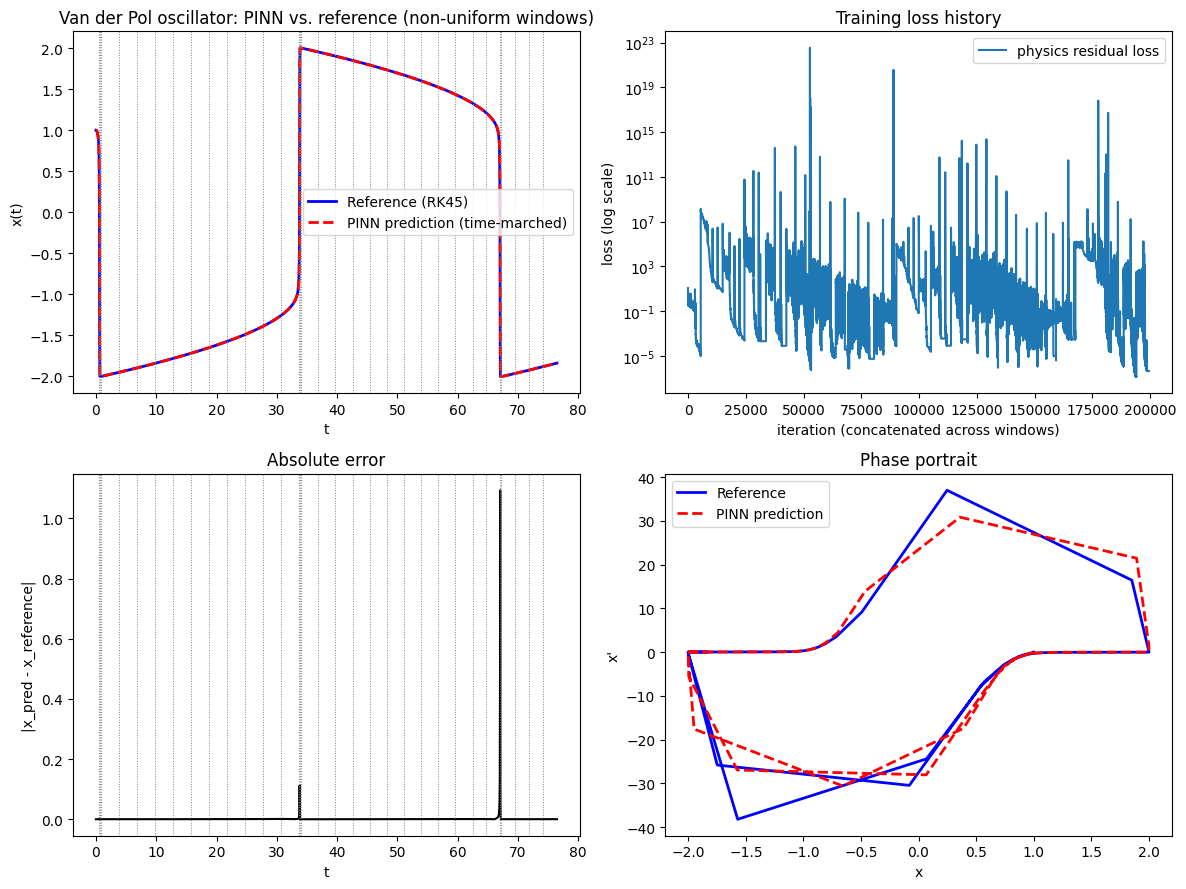

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(t_eval, x_reference, "b-", linewidth=2, label="Reference (RK45)")
axes[0, 0].plot(t_eval, x_pred, "r--", linewidth=2, label="PINN prediction (time-marched)")
for edge in window_edges[1:-1]:
    axes[0, 0].axvline(edge, color="gray", linestyle=":", linewidth=0.7)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("x(t)")
axes[0, 0].set_title("Van der Pol oscillator: PINN vs. reference (non-uniform windows)")
axes[0, 0].legend()

axes[0, 1].semilogy(full_history, label="physics residual loss")
axes[0, 1].set_xlabel("iteration (concatenated across windows)")
axes[0, 1].set_ylabel("loss (log scale)")
axes[0, 1].set_title("Training loss history")
axes[0, 1].legend()

axes[1, 0].plot(t_eval, np.abs(x_pred - x_reference), "k-")
for edge in window_edges[1:-1]:
    axes[1, 0].axvline(edge, color="gray", linestyle=":", linewidth=0.7)
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel("|x_pred - x_reference|")
axes[1, 0].set_title("Absolute error")

x_pred_dot = np.gradient(x_pred, t_eval)
axes[1, 1].plot(x_reference, v_reference, "b-", linewidth=2, label="Reference")
axes[1, 1].plot(x_pred, x_pred_dot, "r--", linewidth=2, label="PINN prediction")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("x'")
axes[1, 1].set_title("Phase portrait")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("pinn_van_der_pol_adaptive_v2_results.png", dpi=150)
plt.show()

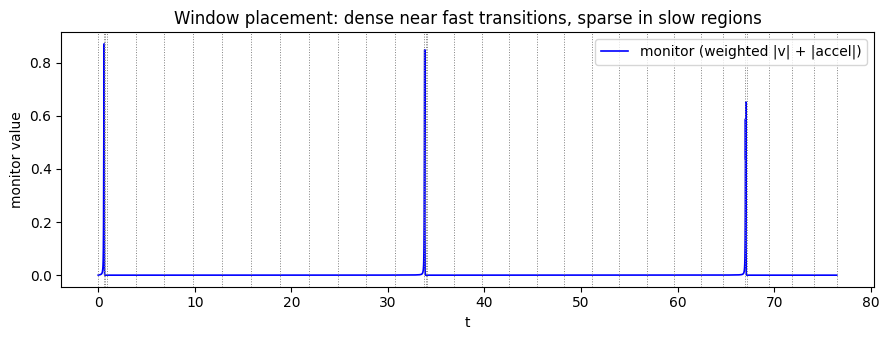

In [14]:
fig2, ax2 = plt.subplots(figsize=(9, 3.5))
ax2.plot(coarse_t, coarse_monitor, "b-", linewidth=1.2, label="monitor (weighted |v| + |accel|)")
for edge in window_edges:
    ax2.axvline(edge, color="gray", linestyle=":", linewidth=0.7)
ax2.set_xlabel("t")
ax2.set_ylabel("monitor value")
ax2.set_title("Window placement: dense near fast transitions, sparse in slow regions")
ax2.legend()
plt.tight_layout()
plt.savefig("window_placement_diagnostic_v2.png", dpi=150)
plt.show()